## Quelles sont les bornes temporelles de la table audience ?

In [1]:
from load_data.donnees_chargement import load_audience

audience = load_audience()
audience.head()

,Annee,TF1,France 2,France 3,Arte
0,1989,41.0,23.4,10.3,NaN
1,1990,41.9,22.1,11.0,NaN
2,1991,42.1,21.3,11.3,NaN
3,1992,41.0,24.0,13.6,NaN
4,1993,41.0,24.7,14.6,0.9


In [2]:
max(audience["Annee"])

2024

In [3]:
min(audience["Annee"])

1989

Les données s'étendent entre 1989 et 2024

## Quelle est l'évolution de l'audience de chaque chaîne

<Axes: title={'center': "Audience totale en fonction de l'année"}, xlabel='Annee'>

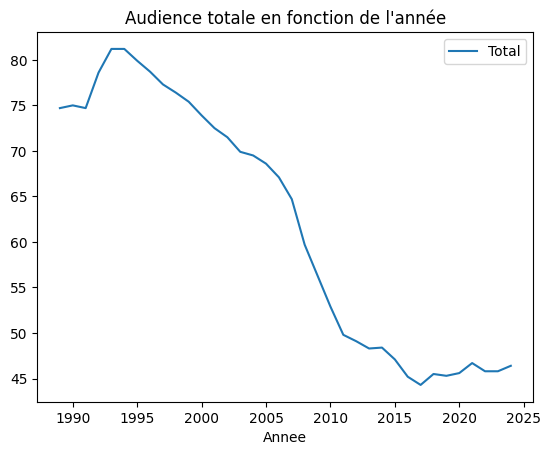

In [4]:
audience_par_annee = audience.drop(columns=["Annee"]).sum(axis=1)
audience["Total"] = audience_par_annee
audience.plot(x="Annee", y="Total", kind="line", title="Audience totale en fonction de l'année")

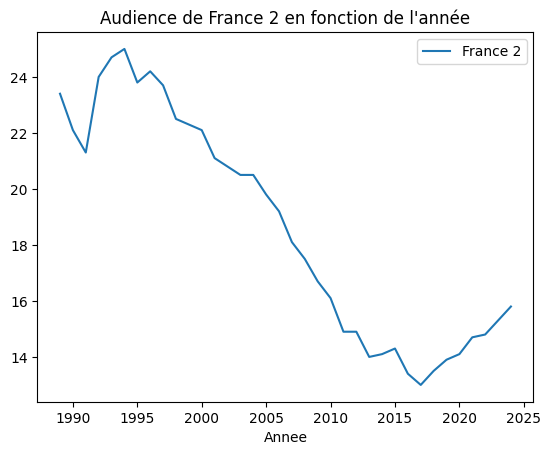

In [5]:
from utilities.utilities import audience_par_annee

audience_par_annee(audience, "Annee", "France 2")

<Axes: title={'center': "Comparaison de l'audience des chaînes TF1, France 2, France 3, Arte en fonction de l'année"}, xlabel='Annee'>

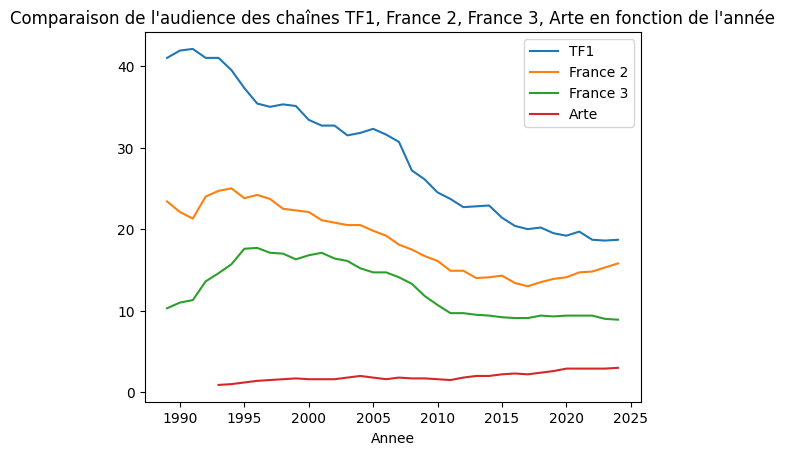

In [6]:
from utilities.utilities import comparaison_audience

comparaison_audience(audience, "Annee", ["TF1", "France 2", "France 3", "Arte"])

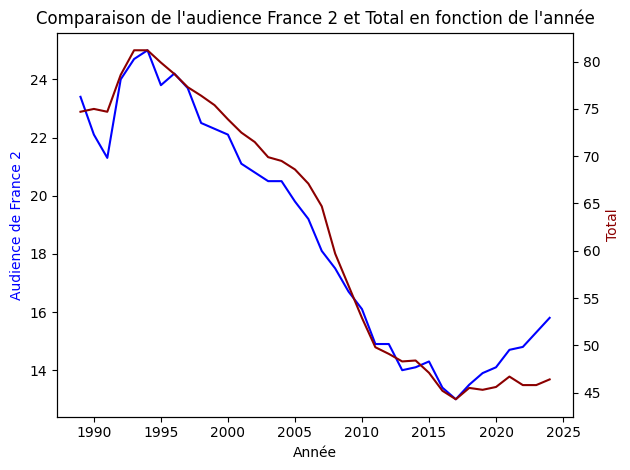

In [7]:
from utilities.utilities import comparaison_audience_axes

comparaison_audience_axes(audience, "Annee", "France 2", "Total")

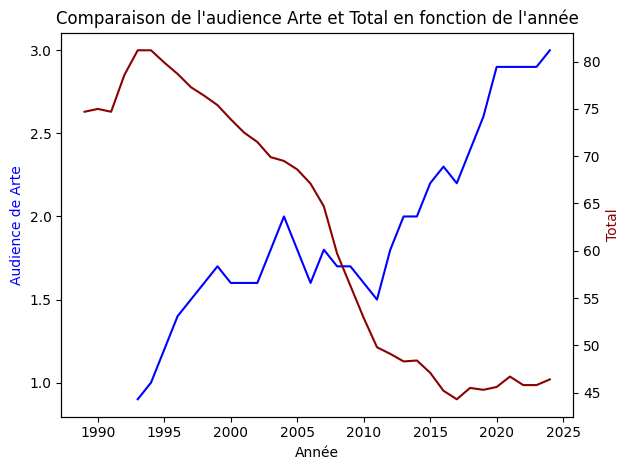

In [8]:
comparaison_audience_axes(audience, "Annee", "Arte", "Total")

# Analyse croisée avec sujet_tele

## Jointure des deux bases

In [9]:
from load_data.donnees_chargement import load_sujet_tele

sujet_tele = load_sujet_tele()
sujet_tele.head()

,Date,Chaîne,Thématique,Nb_sujets,Duree_sec,Temps_total_JT,Prop
0,2000-01-02,France 3,Catastrophes,2,235,1254,0.187400
1,2000-01-02,France 3,Culture-loisirs,1,138,1254,0.110048
2,2000-01-02,France 3,Environnement,3,306,1254,0.244019
3,2000-01-02,France 3,International,2,241,1254,0.192185
4,2000-01-02,France 3,Société,2,160,1254,0.127592


La table sujet_tele est au format long, il faut donc convertir audience en format long

In [10]:
audience_long = audience.melt(
    id_vars="Annee",
    var_name="Chaine",
    value_name="Audience"
)

In [11]:
audience_long.head()

,Annee,Chaine,Audience
0,1989,TF1,41.0
1,1990,TF1,41.9
2,1991,TF1,42.1
3,1992,TF1,41.0
4,1993,TF1,41.0


La table sujet_annee date les évènements par jour. Convertissons les en années

In [12]:
from utilities.utilities import sujet_convert
from load_data.donnees_chargement import load_sujet_tele

sujet_tele_year = sujet_convert(indic='Y', table = load_sujet_tele())
sujet_tele_year["Date"] = sujet_tele_year["Date"].astype(str).astype(int)

In [13]:
sujet_tele_year.head()

,Date,Chaîne,Thématique,Temps cumul,Temps moyen
0,2000,Arte,Catastrophes,9328,89.692308
1,2000,Arte,Culture-loisirs,53981,213.363636
2,2000,Arte,Economie,34342,180.747368
3,2000,Arte,Education,3641,173.380952
4,2000,Arte,Environnement,15859,153.970874


Jointure des deux tables.

In [14]:
import pandas as pd

sujet_audience = pd.merge(sujet_tele_year, 
                          audience_long, 
                          left_on=["Date", "Chaîne"], 
                          right_on=["Annee", "Chaine"]
                          ).drop(columns=["Annee", "Chaine"])

In [15]:
sujet_audience.head()

,Date,Chaîne,Thématique,Temps cumul,Temps moyen,Audience
0,2000,Arte,Catastrophes,9328,89.692308,1.6
1,2000,Arte,Culture-loisirs,53981,213.363636,1.6
2,2000,Arte,Economie,34342,180.747368,1.6
3,2000,Arte,Education,3641,173.380952,1.6
4,2000,Arte,Environnement,15859,153.970874,1.6


## Analyse 

### Croisement thématique/audience par chaîne

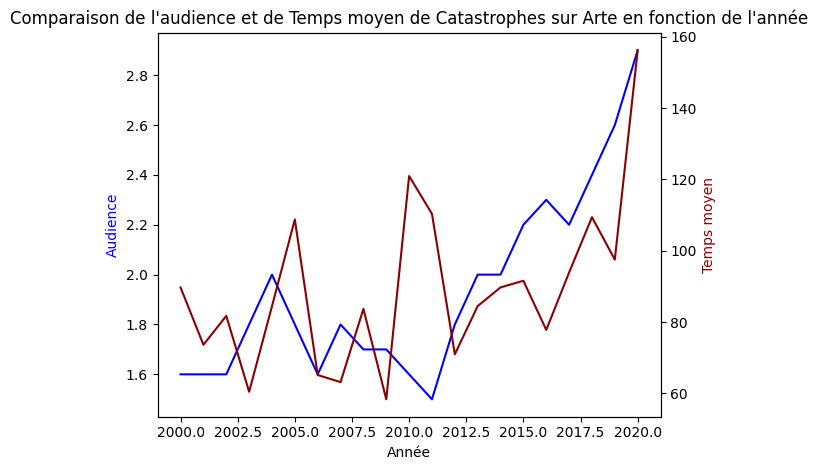

In [16]:
from utilities.utilities import evolution_audience_sujet_chaine

evolution_audience_sujet_chaine(sujet_audience, "Catastrophes", "Arte")

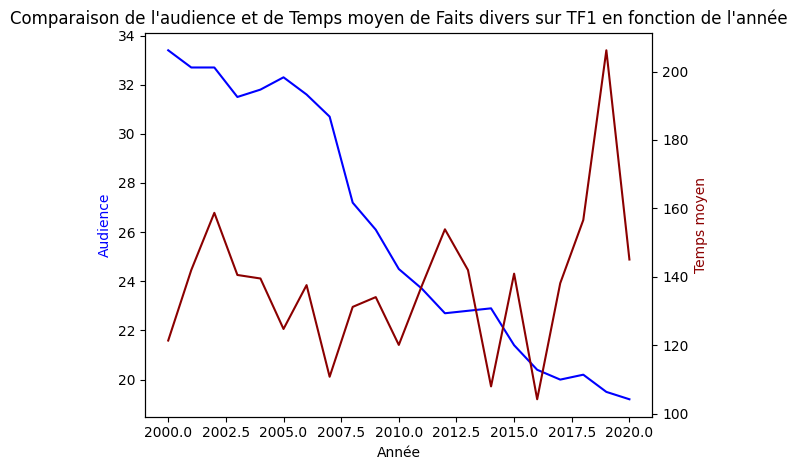

In [17]:
evolution_audience_sujet_chaine(sujet_audience, "Faits divers", "TF1")

Calcul de la corrélation entre le temps moyen d'une thématique et de la part d'audience delon les chaînes.

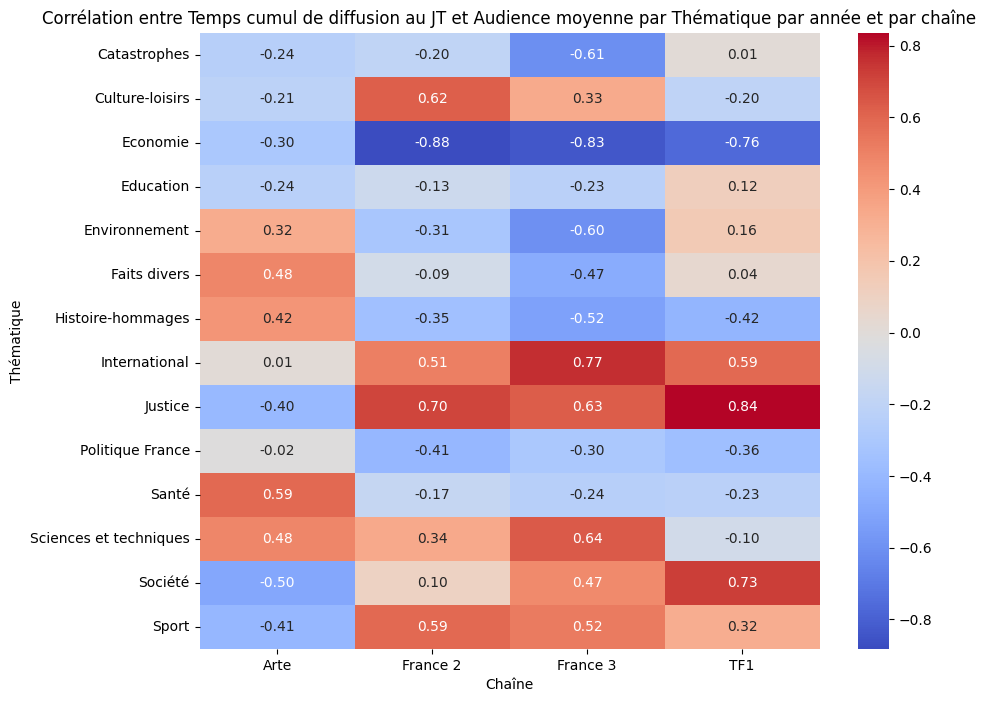

In [18]:
from utilities.utilities import correlation_theme_audience

correlation_theme_audience(sujet_audience, Temps="Temps cumul")

Interprétation: plus une chaîne a abordé un sujet depuis 1989 plus l'audience est forte (corrélation possitive).

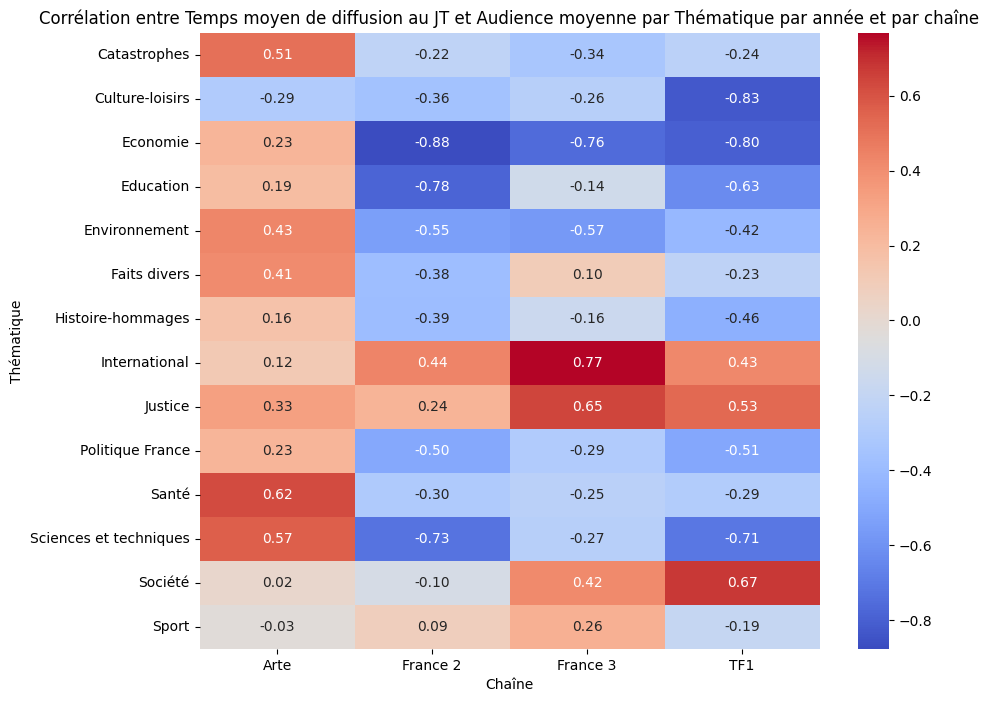

In [19]:
correlation_theme_audience(sujet_audience)

Interprétation: Plus une chaîne aborde un sujet l'année X plus son audience augmente l'année X (corrélation positive).

Puisque Arte est en croissance depuis sa création en terme d'audience, il est naturelle d'observer que les corrélations sont neutre ou positive pour la majeure partie des thématiques. Il serait intéressant de s'intéresser à l'intervalle de confiance de la corrélation concernant le thème Culture-loisir.

Nous allons calculer l'intervalle de confiance. La corrélation est calculée via le coefficient de corrélation de Pearson. Nous utilisons la transformation de Fisher (arctangente) pour se reporter à une statistique suivant asymptotiquement une loi Normale avec un écart-type: 1/ (n-3)^0.5

In [20]:
culture_loisir = sujet_audience[(sujet_audience["Chaîne"]=="Arte") & 
                                (sujet_audience["Thématique"]=="Culture-loisirs")]
corr = culture_loisir["Temps moyen"].corr(culture_loisir["Audience"])
corr

np.float64(-0.2930591263934677)

In [21]:
import numpy as np
# Transformation de Fisher
fisher_corr = np.arctanh(corr)
# Cacul de l'écart-type de la distribution de Fisher
se = 1 / np.sqrt(culture_loisir.shape[0] - 3)
# Calcul de l'intervalle de confiance à 95% pour la corrélation transformée
fisher_low = fisher_corr - 1.96 * se
fisher_high = fisher_corr + 1.96 * se
# Transformation inverse de Fisher pour obtenir l'intervalle de confiance pour la corrélation
ci_low = np.tanh(fisher_low)
ci_high = np.tanh(fisher_high)
print(f"Intervalle de confiance à 95% : [{ci_low:.2f}, {ci_high:.2f}]")



Intervalle de confiance à 95% : [-0.64, 0.16]


0 est compris dans l'intevalle donc on ne rejette pas l'hypothèse que la corrélation soit nulle.

Nous nous demandons s'il y a des corrélations qui sont significatives.

In [22]:
from tqdm import tqdm
from scipy import stats


dic = []

for i in sujet_audience["Chaîne"].unique():
    for j in sujet_audience["Thématique"].unique():
        # Création d'une sous-partie du DataFrame pour la chaîne et la thématique spécifiques
        subset = sujet_audience[(sujet_audience["Chaîne"] == i) & (sujet_audience["Thématique"] == j)] 
        corr = subset["Temps moyen"].corr(subset["Audience"])

        # Calcul de la p-value pour la corrélation
        # # Statistique t
        t = corr * np.sqrt((subset.shape[0] - 2) / (1 - corr**2))
        # P-value bilatérale
        p_value = 2 * stats.t.sf(np.abs(t), df=subset.shape[0]-2)
        # Significativité
        if p_value < 0.05:
            signif = "Significatif"
        else:
            signif = "Non significatif"
        
        dic.append({
            "Chaîne": i,
            "Thématique": j,
            "Corrélation": corr,
            "P-value": p_value,
            "Significativité":signif
        })

corr_significatif = pd.DataFrame(dic)
corr_significatif.head()

,Chaîne,Thématique,Corrélation,P-value,Significativité
0,Arte,Catastrophes,0.508948,0.018461,Significatif
1,Arte,Culture-loisirs,-0.293059,0.197307,Non significatif
2,Arte,Economie,0.233925,0.307450,Non significatif
3,Arte,Education,0.190488,0.408188,Non significatif
4,Arte,Environnement,0.429957,0.051729,Non significatif


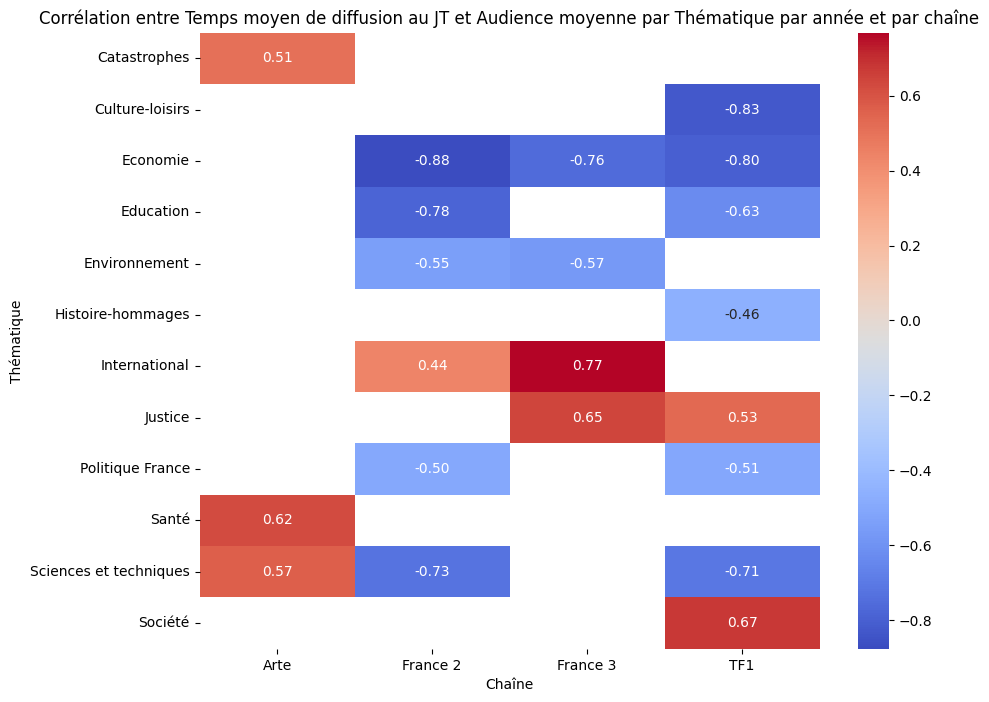

In [23]:
correlation_theme_audience(corr = corr_significatif[
    corr_significatif["Significativité"] == "Significatif"
    ].drop(columns=["P-value", "Significativité"]
           ).pivot(index="Thématique",
                   columns="Chaîne",
                   values="Corrélation"
                   )
    )